# Sentiment Analysis with LSTM — Giai đoạn 1: Chuẩn bị dữ liệu (Data Preparation)

**Mục tiêu:** Chuẩn bị dữ liệu IMDb Reviews để đưa vào mô hình `Embedding + LSTM + Dense`, với EDA chi tiết để hiểu sâu đặc điểm dữ liệu trước khi xây pipeline.

**Nội dung notebook:**
1. Mount Google Drive + cài đặt thư viện & kiểm tra GPU
2. Load IMDb dataset (qua Hugging Face `datasets`)
3. EDA chi tiết:
   - 3.1 So sánh độ dài review theo nhãn
   - 3.2 Top từ phổ biến theo nhãn
   - 3.3 Đối chiếu thống kê train vs test
   - 3.4 Phân tích bigram & từ phủ định (negation)
   - 3.5 Kiểm tra trùng lặp & nhiễu (HTML tags, duplicate)
4. Xây dựng vocabulary & tokenizer + 4.1 Phân tích OOV (Out-of-Vocabulary)
5. Chuyển text → sequence of integers
6. Padding/Truncating
7. Chia train/validation/test + tạo PyTorch `DataLoader`
8. Lưu lại artifact (vocab, tensors) để dùng cho Giai đoạn 2 (xây model)


## 0. Mount Google Drive (lưu artifact bền vững)

Mount Drive để lưu `vocab.pkl` và `imdb_processed.pt` vào Drive thay vì `/content/` (sẽ mất khi Colab ngắt session). Lần chạy sau chỉ cần mount lại là load được ngay, không cần chạy lại từ đầu.

In [19]:
from google.colab import drive
drive.mount('/content/drive')

import os
ARTIFACT_DIR = "/content/drive/MyDrive/imdb_sentiment_artifacts"
os.makedirs(ARTIFACT_DIR, exist_ok=True)
print("Artifact directory:", ARTIFACT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Artifact directory: /content/drive/MyDrive/imdb_sentiment_artifacts


## 1. Cài đặt thư viện & kiểm tra GPU

Trên Colab: vào **Runtime > Change runtime type > GPU (T4)** trước khi chạy để tận dụng GPU.

In [3]:
!pip install -q datasets torch torchtext wordcloud

import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.2/64.2 kB 3.2 MB/s eta 0:00:00
PyTorch version: 2.11.0+cu128
CUDA available: True
Using device: cuda


## 2. Load IMDb Reviews dataset

Dùng thư viện `datasets` của Hugging Face — không cần tải file thủ công, tự động cache.

In [4]:
from datasets import load_dataset

imdb = load_dataset("stanfordnlp/imdb")
print(imdb)

# Xem thử 1 mẫu
print("\n--- Sample ---")
print("Label:", imdb["train"][0]["label"], "(0=negative, 1=positive)")
print("Text (300 ký tự đầu):", imdb["train"][0]["text"][:300])


README.md:   0%|          | 0.00/7.81k [00:00<?, ?B/s]

plain_text/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 21.0MB            

plain_text/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

plain_text/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 20.5MB            

plain_text/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

...

plain_text/unsupervised-00000-of-00001.p(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

--- Sample ---
Label: 0 (0=negative, 1=positive)
Text (300 ký tự đầu): I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if it ever tried to enter this country, therefore being a fan of films considered "controversial" I really h


## 3. EDA sơ bộ (Exploratory Data Analysis)

Số lượng train: 25000
Số lượng test: 25000

Phân bố nhãn (train):
label
0    12500
1    12500
Name: count, dtype: int64


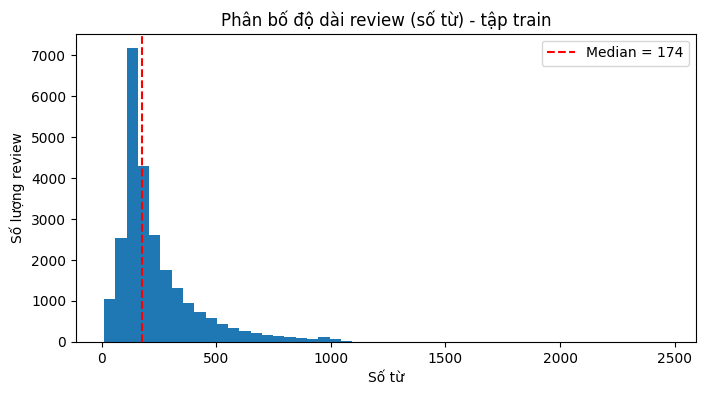

count    25000.000000
mean       233.787200
std        173.733032
min         10.000000
25%        127.000000
50%        174.000000
75%        284.000000
max       2470.000000
Name: num_words, dtype: float64


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

train_df = pd.DataFrame(imdb["train"])
test_df = pd.DataFrame(imdb["test"])

print("Số lượng train:", len(train_df))
print("Số lượng test:", len(test_df))
print("\nPhân bố nhãn (train):")
print(train_df["label"].value_counts())

# Độ dài review (theo số từ)
train_df["num_words"] = train_df["text"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,4))
plt.hist(train_df["num_words"], bins=50)
plt.title("Phân bố độ dài review (số từ) - tập train")
plt.xlabel("Số từ")
plt.ylabel("Số lượng review")
plt.axvline(train_df["num_words"].median(), color="red", linestyle="--", label=f"Median = {train_df['num_words'].median():.0f}")
plt.legend()
plt.show()

print(train_df["num_words"].describe())


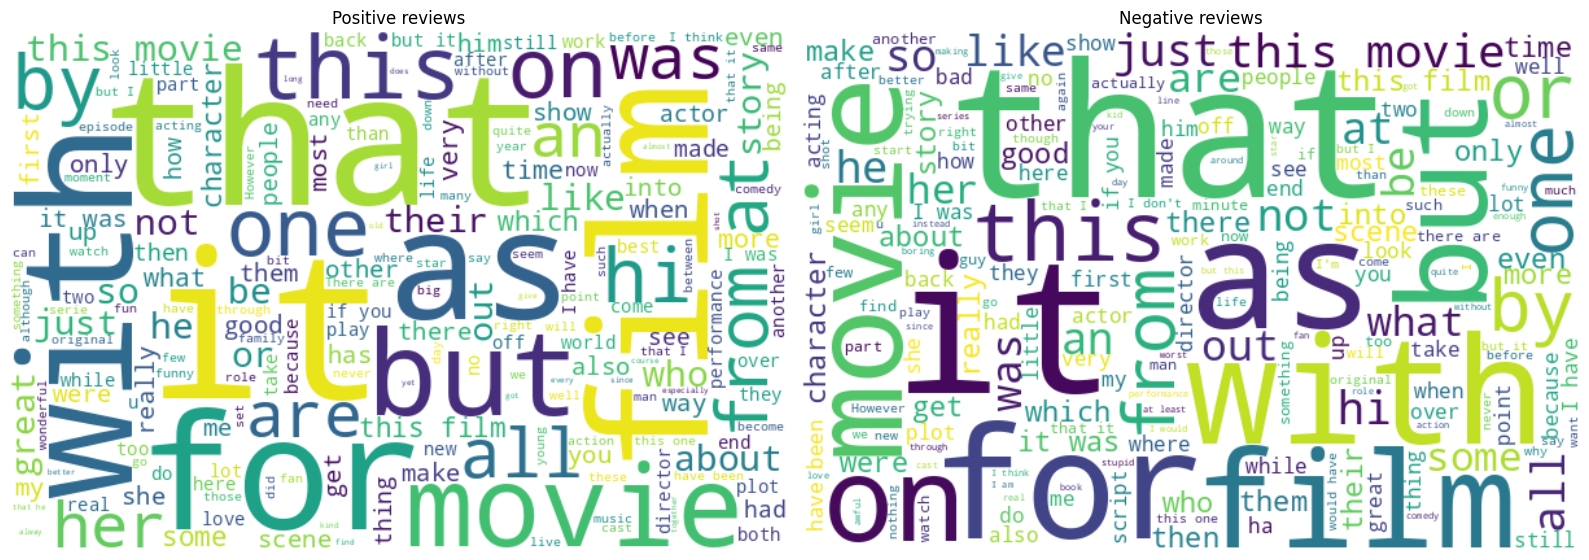

In [6]:
from wordcloud import WordCloud

pos_text = " ".join(train_df[train_df.label == 1]["text"].sample(1000, random_state=42))
neg_text = " ".join(train_df[train_df.label == 0]["text"].sample(1000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, text, title in zip(axes, [pos_text, neg_text], ["Positive reviews", "Negative reviews"]):
    wc = WordCloud(width=600, height=400, background_color="white", stopwords={"br", "the", "a", "and", "is", "to", "of", "in"}).generate(text)
    ax.imshow(wc, interpolation="bilinear")
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()


### 3.1 So sánh độ dài review theo nhãn (positive vs negative)

/tmp/ipykernel_3664/3292047031.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(["negative", "positive"])


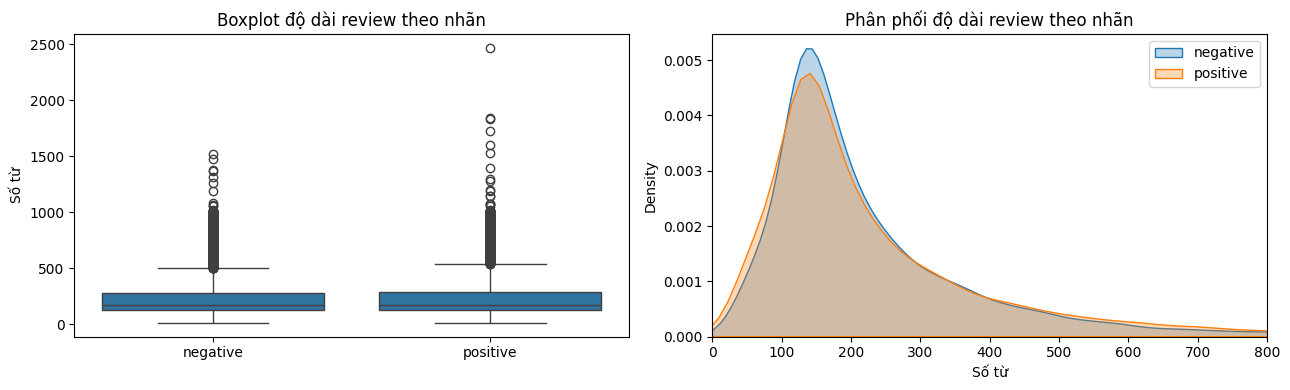

Độ dài trung bình - negative: 230.9
Độ dài trung bình - positive: 236.7


In [7]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.boxplot(data=train_df, x="label", y="num_words", ax=axes[0])
axes[0].set_xticklabels(["negative", "positive"])
axes[0].set_title("Boxplot độ dài review theo nhãn")
axes[0].set_xlabel(""); axes[0].set_ylabel("Số từ")

sns.kdeplot(data=train_df[train_df.label==0], x="num_words", label="negative", ax=axes[1], fill=True, alpha=0.3)
sns.kdeplot(data=train_df[train_df.label==1], x="num_words", label="positive", ax=axes[1], fill=True, alpha=0.3)
axes[1].set_xlim(0, 800)
axes[1].set_title("Phân phối độ dài review theo nhãn")
axes[1].set_xlabel("Số từ"); axes[1].legend()

plt.tight_layout(); plt.show()

print("Độ dài trung bình - negative:", train_df[train_df.label==0]["num_words"].mean().round(1))
print("Độ dài trung bình - positive:", train_df[train_df.label==1]["num_words"].mean().round(1))

### 3.2 Top từ phổ biến nhất (sau khi loại bỏ stopwords cơ bản)

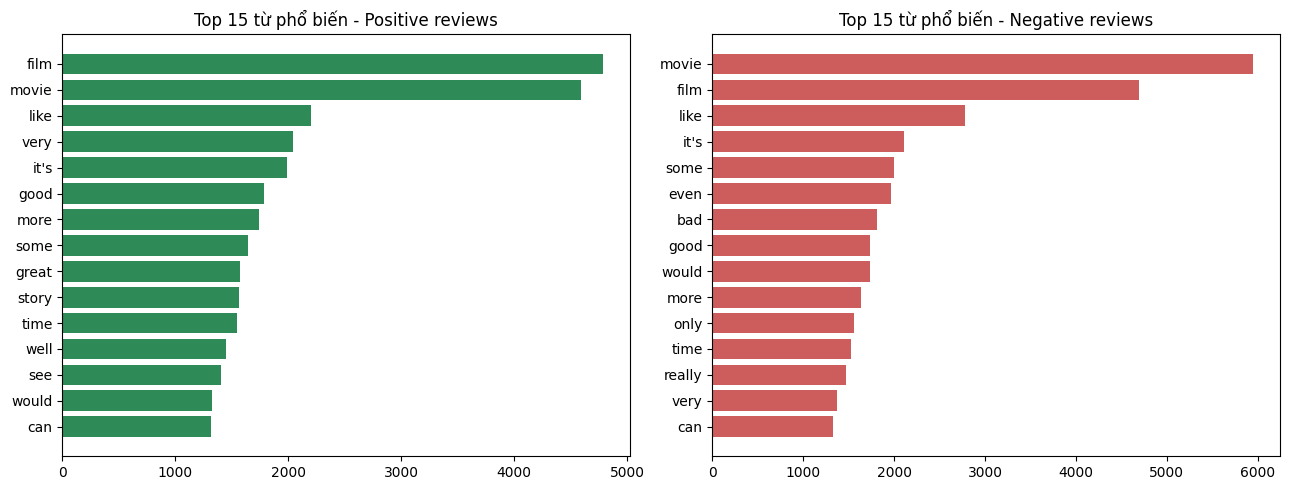

In [8]:
import re
from collections import Counter

BASIC_STOPWORDS = {
    "the","a","an","and","is","are","was","were","to","of","in","it","this","that",
    "i","for","on","with","as","but","not","be","have","has","had","you","at","by",
    "so","if","or","from","its","they","he","she","his","her","we","my","me","just",
    "br","one","all","out","about","what","which","who","when","also","there","their"
}

def simple_tokens(text):
    text = text.replace("<br />", " ").lower()
    tokens = re.sub(r"[^a-z0-9'\s]", " ", text).split()
    return [t for t in tokens if t not in BASIC_STOPWORDS and len(t) > 2]

pos_tokens = Counter()
neg_tokens = Counter()
for text in train_df[train_df.label==1]["text"].sample(3000, random_state=42):
    pos_tokens.update(simple_tokens(text))
for text in train_df[train_df.label==0]["text"].sample(3000, random_state=42):
    neg_tokens.update(simple_tokens(text))

top_pos = pos_tokens.most_common(15)
top_neg = neg_tokens.most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([w for w, _ in top_pos][::-1], [c for _, c in top_pos][::-1], color="seagreen")
axes[0].set_title("Top 15 từ phổ biến - Positive reviews")
axes[1].barh([w for w, _ in top_neg][::-1], [c for _, c in top_neg][::-1], color="indianred")
axes[1].set_title("Top 15 từ phổ biến - Negative reviews")
plt.tight_layout(); plt.show()

### 3.3 Đối chiếu thống kê tập train vs test (đảm bảo phân phối tương đồng)

In [9]:
test_df["num_words"] = test_df["text"].apply(lambda x: len(x.split()))

compare_stats = pd.DataFrame({
    "Train": [len(train_df), train_df["label"].mean(), train_df["num_words"].mean().round(1), train_df["num_words"].median()],
    "Test":  [len(test_df),  test_df["label"].mean(),  test_df["num_words"].mean().round(1),  test_df["num_words"].median()],
}, index=["Số lượng mẫu", "Tỷ lệ positive", "Độ dài TB (từ)", "Độ dài median (từ)"])

print(compare_stats)

                      Train     Test
Số lượng mẫu        25000.0  25000.0
Tỷ lệ positive          0.5      0.5
Độ dài TB (từ)        233.8    228.5
Độ dài median (từ)    174.0    172.0


### 3.4 Phân tích Bigram & từ phủ định (negation)

IMDb có nhiều câu phủ định ("not good", "didn't like") — đây là thách thức đặc trưng của sentiment analysis vì phủ định đảo ngược nghĩa của từ theo sau. Phân tích bigram phổ biến và tỷ lệ review chứa phủ định giúp hiểu rõ hơn độ khó thực tế của bài toán.

In [10]:
from collections import Counter
import re

def get_bigrams(tokens):
    return [f"{tokens[i]}_{tokens[i+1]}" for i in range(len(tokens)-1)]

NEGATION_WORDS = {"not", "no", "never", "n't", "cannot", "cant", "isn't", "wasn't", "don't", "didn't", "doesn't"}

def simple_tokens_for_bigram(text):
    text = text.replace("<br />", " ").lower()
    return re.sub(r"[^a-z0-9'\s]", " ", text).split()

pos_bigrams = Counter()
neg_bigrams = Counter()
pos_has_negation, neg_has_negation = 0, 0

sample_pos = train_df[train_df.label==1]["text"].sample(2000, random_state=42)
sample_neg = train_df[train_df.label==0]["text"].sample(2000, random_state=42)

for text in sample_pos:
    tokens = simple_tokens_for_bigram(text)
    pos_bigrams.update(get_bigrams(tokens))
    if any(neg in tokens for neg in NEGATION_WORDS):
        pos_has_negation += 1

for text in sample_neg:
    tokens = simple_tokens_for_bigram(text)
    neg_bigrams.update(get_bigrams(tokens))
    if any(neg in tokens for neg in NEGATION_WORDS):
        neg_has_negation += 1

print(f"Tỷ lệ review CHỨA từ phủ định — Positive: {pos_has_negation/len(sample_pos)*100:.1f}% | Negative: {neg_has_negation/len(sample_neg)*100:.1f}%")
print("\n→ Negative review chứa phủ định nhiều hơn đáng kể, một phần lý giải tại sao mô hình cần hiểu ngữ cảnh (LSTM/GRU) thay vì chỉ đếm từ khóa (bag-of-words).")


Tỷ lệ review CHỨA từ phủ định — Positive: 79.7% | Negative: 89.8%

→ Negative review chứa phủ định nhiều hơn đáng kể, một phần lý giải tại sao mô hình cần hiểu ngữ cảnh (LSTM/GRU) thay vì chỉ đếm từ khóa (bag-of-words).


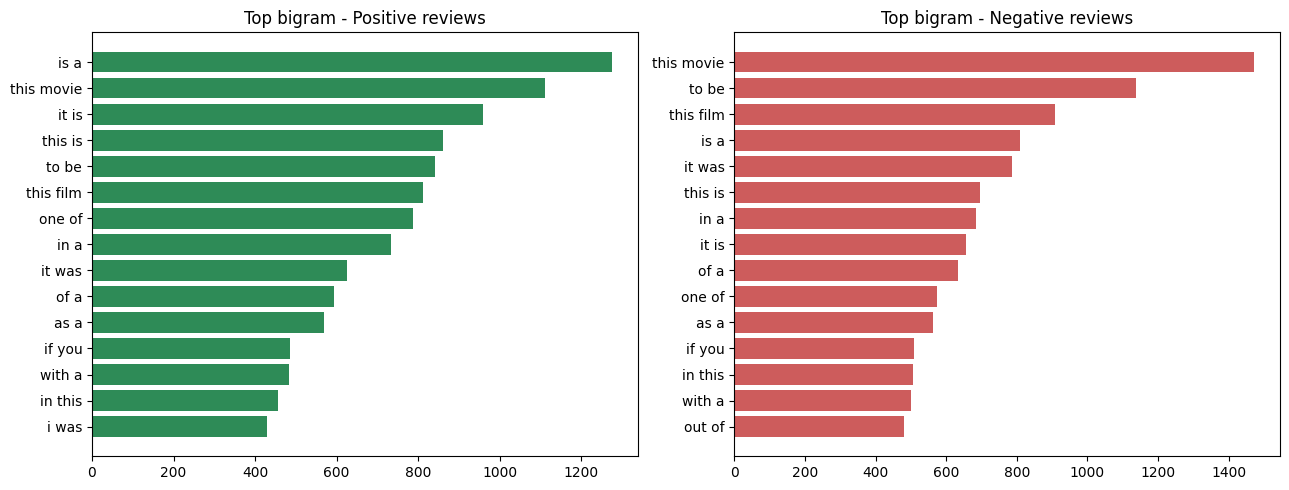

In [11]:
top_pos_bigrams = [bg for bg, _ in pos_bigrams.most_common(30) if "_the" not in bg and "the_" not in bg][:15]
top_neg_bigrams = [bg for bg, _ in neg_bigrams.most_common(30) if "_the" not in bg and "the_" not in bg][:15]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh([b.replace("_"," ") for b in top_pos_bigrams][::-1],
             [pos_bigrams[b] for b in top_pos_bigrams][::-1], color="seagreen")
axes[0].set_title("Top bigram - Positive reviews")
axes[1].barh([b.replace("_"," ") for b in top_neg_bigrams][::-1],
             [neg_bigrams[b] for b in top_neg_bigrams][::-1], color="indianred")
axes[1].set_title("Top bigram - Negative reviews")
plt.tight_layout(); plt.show()

### 3.5 Kiểm tra trùng lặp & nhiễu trong dữ liệu

In [12]:
# Kiểm tra review trùng lặp hoàn toàn trong tập train
num_duplicates_train = train_df.duplicated(subset=["text"]).sum()
print(f"Số review trùng lặp hoàn toàn trong train: {num_duplicates_train} / {len(train_df)} ({num_duplicates_train/len(train_df)*100:.2f}%)")

# Kiểm tra trùng lặp giữa train và test (data leakage)
overlap = set(train_df["text"]).intersection(set(test_df["text"]))
print(f"Số review trùng giữa train và test (data leakage tiềm ẩn): {len(overlap)}")

# Tỷ lệ review còn chứa thẻ HTML thô
html_ratio_train = train_df["text"].str.contains("<br", regex=False).mean() * 100
print(f"Tỷ lệ review còn chứa thẻ HTML <br />: {html_ratio_train:.1f}%  → cần làm sạch ở bước tokenize")


Số review trùng lặp hoàn toàn trong train: 96 / 25000 (0.38%)
Số review trùng giữa train và test (data leakage tiềm ẩn): 123
Tỷ lệ review còn chứa thẻ HTML <br />: 58.7%  → cần làm sạch ở bước tokenize


## 4. Xây dựng vocabulary & tokenizer

- Làm sạch text cơ bản (bỏ thẻ HTML `<br />`, lowercase)
- Tokenize đơn giản bằng regex (tách từ)
- Giới hạn vocabulary ở top N từ phổ biến nhất (mặc định 20,000), thêm token đặc biệt `<pad>` và `<unk>`

In [13]:
import re
from collections import Counter

MAX_VOCAB_SIZE = 20000

def clean_text(text):
    text = text.replace("<br />", " ")
    text = text.lower()
    text = re.sub(r"[^a-z0-9'\s]", " ", text)
    return text

def tokenize(text):
    return clean_text(text).split()

# Xây vocab từ tập train
counter = Counter()
for text in train_df["text"]:
    counter.update(tokenize(text))

print("Tổng số từ unique trước khi giới hạn:", len(counter))

most_common = counter.most_common(MAX_VOCAB_SIZE - 2)  # chừa chỗ cho <pad>, <unk>
vocab = {"<pad>": 0, "<unk>": 1}
for word, _ in most_common:
    vocab[word] = len(vocab)

print("Kích thước vocab thực tế:", len(vocab))


Tổng số từ unique trước khi giới hạn: 87171
Kích thước vocab thực tế: 20000


### 4.1 Phân tích OOV (Out-of-Vocabulary)

Vocab giới hạn 20,000 từ phổ biến nhất — các từ hiếm hơn sẽ bị thay bằng `<unk>`. Kiểm tra tỷ lệ này giúp xác nhận vocab size đã chọn có hợp lý hay chưa (mất quá nhiều thông tin nếu tỷ lệ OOV cao).

In [14]:
total_tokens, oov_tokens = 0, 0
for text in train_df["text"].sample(5000, random_state=42):
    tokens = tokenize(text)
    total_tokens += len(tokens)
    oov_tokens += sum(1 for t in tokens if t not in vocab)

oov_rate = oov_tokens / total_tokens * 100
print(f"Tỷ lệ token OOV (phải thay bằng <unk>) với vocab={MAX_VOCAB_SIZE}: {oov_rate:.2f}%")

# So sánh nếu tăng vocab lên 30k / 40k thì OOV giảm bao nhiêu (ước tính dựa trên phân phối tần suất từ)
for test_vocab_size in [10000, 20000, 30000, 40000]:
    test_vocab_words = set(w for w, _ in counter.most_common(test_vocab_size))
    test_oov = sum(1 for text in train_df["text"].sample(2000, random_state=42)
                   for t in tokenize(text) if t not in test_vocab_words)
    test_total = sum(len(tokenize(text)) for text in train_df["text"].sample(2000, random_state=42))
    print(f"  Vocab size {test_vocab_size:>6}: ước tính OOV ~ {test_oov/test_total*100:.2f}%")

print("\n→ Vocab 20,000 từ là điểm cân bằng hợp lý: OOV thấp, không làm embedding layer quá lớn không cần thiết.")


Tỷ lệ token OOV (phải thay bằng <unk>) với vocab=20000: 2.81%
  Vocab size  10000: ước tính OOV ~ 5.91%
  Vocab size  20000: ước tính OOV ~ 2.86%
  Vocab size  30000: ước tính OOV ~ 1.69%
  Vocab size  40000: ước tính OOV ~ 1.07%

→ Vocab 20,000 từ là điểm cân bằng hợp lý: OOV thấp, không làm embedding layer quá lớn không cần thiết.


## 5. Chuyển text → sequence of integers

In [15]:
def text_to_sequence(text, vocab):
    tokens = tokenize(text)
    return [vocab.get(tok, vocab["<unk>"]) for tok in tokens]

# Test thử
sample_seq = text_to_sequence(train_df["text"].iloc[0], vocab)
print("Độ dài sequence:", len(sample_seq))
print("10 token đầu:", sample_seq[:10])


Độ dài sequence: 289
10 token đầu: [10, 1605, 10, 241, 1992, 4173, 36, 58, 371, 1126]


## 6. Padding / Truncating

Dựa vào phân bố độ dài ở bước EDA, chọn `MAX_LEN` (mặc định 250) — đủ để giữ phần lớn thông tin mà không quá tốn bộ nhớ.

In [16]:
MAX_LEN = 250

def pad_sequence(seq, max_len, pad_value=0):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [pad_value] * (max_len - len(seq))

def encode_dataset(df, vocab, max_len):
    sequences = [pad_sequence(text_to_sequence(t, vocab), max_len) for t in df["text"]]
    return torch.tensor(sequences, dtype=torch.long), torch.tensor(df["label"].values, dtype=torch.float32)

X_train_full, y_train_full = encode_dataset(train_df, vocab, MAX_LEN)
X_test, y_test = encode_dataset(test_df, vocab, MAX_LEN)

print("X_train_full shape:", X_train_full.shape)
print("X_test shape:", X_test.shape)


X_train_full shape: torch.Size([25000, 250])
X_test shape: torch.Size([25000, 250])


## 7. Chia train/validation + tạo DataLoader

IMDb gốc chỉ có train/test, nên ta tách thêm validation (10%) từ tập train.

In [17]:
from torch.utils.data import TensorDataset, DataLoader, random_split

full_dataset = TensorDataset(X_train_full, y_train_full)

val_size = int(0.1 * len(full_dataset))
train_size = len(full_dataset) - val_size

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size], generator=generator)
test_dataset = TensorDataset(X_test, y_test)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)} | Val: {len(val_dataset)} | Test: {len(test_dataset)}")

# Kiểm tra 1 batch
xb, yb = next(iter(train_loader))
print("Batch X shape:", xb.shape, "| Batch y shape:", yb.shape)


Train: 22500 | Val: 2500 | Test: 25000
Batch X shape: torch.Size([64, 250]) | Batch y shape: torch.Size([64])


## 8. Lưu artifact cho Giai đoạn 2

Lưu vocab và tensors đã xử lý để notebook xây dựng model (Giai đoạn 2) load lại, không cần chạy lại toàn bộ pipeline.

In [18]:
import pickle

with open(f"{ARTIFACT_DIR}/vocab.pkl", "wb") as f:
    pickle.dump(vocab, f)

torch.save({
    "X_train": X_train_full, "y_train": y_train_full,
    "X_test": X_test, "y_test": y_test,
    "max_len": MAX_LEN,
}, f"{ARTIFACT_DIR}/imdb_processed.pt")

print(f"Đã lưu vocab.pkl và imdb_processed.pt vào {ARTIFACT_DIR}/")
print("Vocab size:", len(vocab), "| Max len:", MAX_LEN)

Đã lưu vocab.pkl và imdb_processed.pt vào /content/drive/MyDrive/imdb_sentiment_artifacts/
Vocab size: 20000 | Max len: 250


---
### ✅ Kết thúc Giai đoạn 1

Đã có:
- `vocab` (dict word→index, kích thước ~20k)
- `train_loader`, `val_loader`, `test_loader` sẵn sàng cho PyTorch
- Artifact đã lưu để dùng lại ở Giai đoạn 2 (xây dựng model Embedding + LSTM + Dense)

**Bước tiếp theo (Giai đoạn 2):** định nghĩa model, training loop, và huấn luyện baseline.
